In [28]:
# Importing Libraries
import os
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, classification_report, confusion_matrix
from transformers import pipeline
import re
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")


In [29]:
# Define the dataset directory
DATASET_DIR = 'UTKFace'  # Update this path based on your setup


In [30]:
def parse_age(filename):
    """
    Parses the age from the filename.

    Parameters:
    - filename (str): The name of the image file.

    Returns:
    - age (int): The extracted age.
    """
    try:
        age = int(filename.split('_')[0])
        return age
    except:
        return None


In [31]:
def get_image_paths(dataset_dir):
    """
    Recursively collects all image file paths from the dataset directory and its subdirectories.

    Parameters:
    - dataset_dir (str): The root directory of the dataset.

    Returns:
    - List[str]: A list of full image file paths.
    """
    image_paths = []
    for root, dirs, files in os.walk(dataset_dir):
        for file in files:
            if file.lower().endswith(('.jpg', '.png')):
                image_paths.append(os.path.join(root, file))
    return image_paths


In [32]:
# Collect all image paths
image_paths = get_image_paths(DATASET_DIR)

# Create DataFrame
data = []
for img_path in image_paths:
    img_name = os.path.basename(img_path)
    age = parse_age(img_name)
    if age is not None:
        data.append({'image_path': img_path, 'age': age})

df = pd.DataFrame(data)
print(f'Total samples: {len(df)}')


Total samples: 23708


In [33]:
# Split the data
train_df, test_df = train_test_split(df, test_size=0.15, random_state=42)
train_df, val_df = train_test_split(train_df, test_size=0.1765, random_state=42)  # 0.1765 * 0.85 ≈ 0.15

print(f'Training samples: {len(train_df)}')
print(f'Validation samples: {len(val_df)}')
print(f'Testing samples: {len(test_df)}')


Training samples: 16594
Validation samples: 3557
Testing samples: 3557


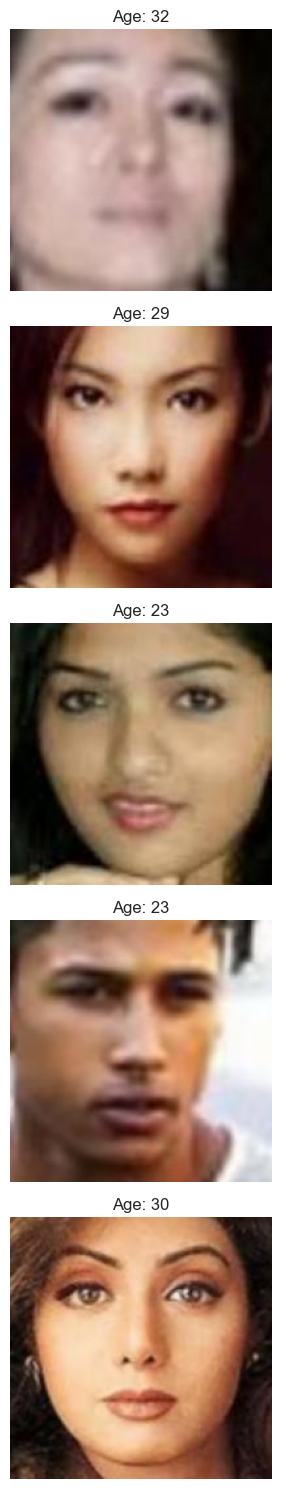

In [34]:
# 6. Display some sample images with their ages
def display_sample_images(df, num_samples=5):
    """
    Displays a specified number of sample images from the DataFrame.

    Parameters:
    - df (pd.DataFrame): The DataFrame containing image paths and ages.
    - num_samples (int): Number of sample images to display.
    """
    samples = df.sample(n=num_samples, random_state=42)
    plt.figure(figsize=(15, 3 * num_samples))
    for idx, (i, row) in enumerate(samples.iterrows(), 1):
        img = Image.open(row['image_path']).convert('RGB')
        plt.subplot(num_samples, 1, idx)
        plt.imshow(img)
        plt.title(f"Age: {row['age']}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Display 5 sample images from the training set
display_sample_images(train_df, num_samples=5)


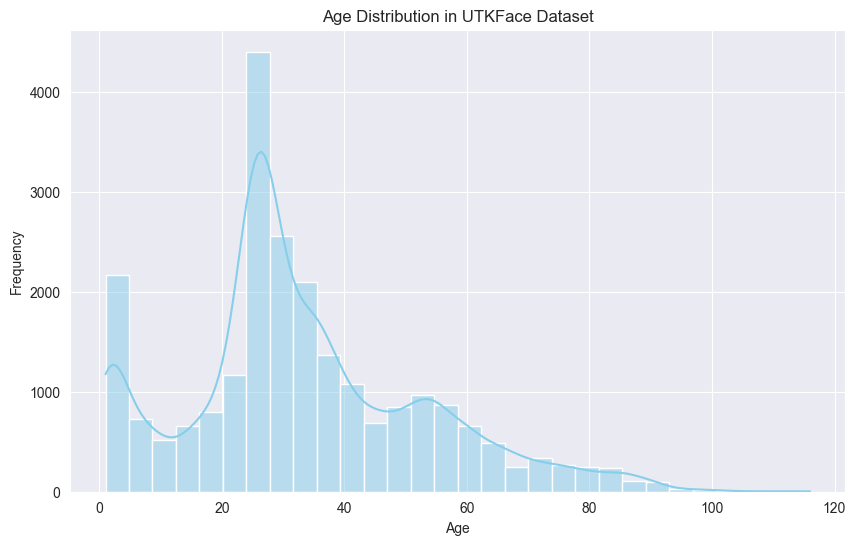

In [35]:
# 7. Plot age distribution
plt.figure(figsize=(10,6))
sns.histplot(df['age'], bins=30, kde=True, color='skyblue')
plt.title('Age Distribution in UTKFace Dataset')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()


In [36]:
# Load Both Models Using Pipelines
print("\nLoading Models...")

# Enable fast image processor for faster predictions
pipe_model1 = pipeline("image-classification", model="dima806/facial_age_image_detection", use_fast=True)
pipe_model2 = pipeline("image-classification", model="nateraw/vit-age-classifier", use_fast=True)

print("Models Loaded Successfully.")



Loading Models...


Device set to use cpu
Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.
Device set to use cpu


Models Loaded Successfully.


In [37]:
# Number of images to use for prediction
NUM_IMAGES = 50  # Adjust based on your computational resources

# Select a subset from the test set
test_subset_df = test_df.sample(n=min(NUM_IMAGES, len(test_df)), random_state=42).reset_index(drop=True)

# Load images
test_images = []
for img_path in tqdm(test_subset_df['image_path'], desc="Loading Test Images"):
    try:
        img = Image.open(img_path).convert('RGB')
        test_images.append(img)
    except Exception as e:
        print(f'Error loading image {img_path}: {e}')
        test_images.append(None)  # Placeholder for failed images

# Remove any failed images
valid_indices = [i for i, img in enumerate(test_images) if img is not None]
test_subset_df = test_subset_df.iloc[valid_indices].reset_index(drop=True)
test_images = [img for img in test_images if img is not None]

print(f'Test subset after removing invalid images: {len(test_images)}')


Loading Test Images: 100%|██████████| 50/50 [00:00<00:00, 2033.44it/s]

Test subset after removing invalid images: 50


In [38]:
def parse_age_label(label):
    """
    Parses the age label from the model's prediction.

    Parameters:
    - label (str): The age label predicted by the model.

    Returns:
    - age (float): The numerical age value.
    """
    # Check if the label is a single number
    if re.match(r'^\d+$', label):
        return float(label)
    # Check if the label is a range like '25-30'
    elif re.match(r'^\d+-\d+$', label):
        ages = label.split('-')
        lower = float(ages[0])
        upper = float(ages[1])
        return (lower + upper) / 2
    # Check for 'more than' or 'less than' formats
    elif label.startswith("more than"):
        age = float(re.findall(r'\d+', label)[0])
        return age + 5  # Assign age as current age + 5 years
    elif label.startswith("less than"):
        age = float(re.findall(r'\d+', label)[0])
        return age - 5  # Assign age as current age - 5 years
    else:
        print(f"Unrecognized label format: {label}")
        return np.nan  # Return NaN for unrecognized formats


In [39]:
# 11. Make Predictions with Both Models
# Model 1 Predictions
print("\nPredicting with dima806/facial_age_image_detection...")
predictions_model1 = []
for img in tqdm(test_images, desc="Model 1 Prediction"):
    preds = pipe_model1(img)
    age_label = preds[0]['label']
    age = parse_age_label(age_label)
    predictions_model1.append(age)

# Model 2 Predictions
print("\nPredicting with nateraw/vit-age-classifier...")
predictions_model2 = []
for img in tqdm(test_images, desc="Model 2 Prediction"):
    preds = pipe_model2(img)
    age_label = preds[0]['label']
    age = parse_age_label(age_label)
    predictions_model2.append(age)



Predicting with dima806/facial_age_image_detection...


Model 1 Prediction: 100%|██████████| 50/50 [00:12<00:00,  3.99it/s]



Predicting with nateraw/vit-age-classifier...


Model 2 Prediction: 100%|██████████| 50/50 [00:11<00:00,  4.31it/s]


In [40]:
# 12. Add Predictions to DataFrame
test_subset_df['pred_model1'] = predictions_model1
test_subset_df['pred_model2'] = predictions_model2

# 13. Data Cleaning: Remove NaN predictions
evaluation_df = test_subset_df.dropna(subset=['pred_model1', 'pred_model2']).reset_index(drop=True)
print(f'Evaluation DataFrame shape: {evaluation_df.shape}')

if evaluation_df.empty:
    print("\nError: No valid predictions found. Please check the label parsing logic and model outputs.")


Evaluation DataFrame shape: (50, 4)


In [41]:
# True ages
true_ages = evaluation_df['age'].values

# Predictions
pred_model1 = evaluation_df['pred_model1'].values
pred_model2 = evaluation_df['pred_model2'].values

# Calculate MAE
mae_model1 = mean_absolute_error(true_ages, pred_model1)
mae_model2 = mean_absolute_error(true_ages, pred_model2)

print(f'\nModel 1 (dima806/facial_age_image_detection) MAE: {mae_model1:.2f} years')
print(f'Model 2 (nateraw/vit-age-classifier) MAE: {mae_model2:.2f} years')



Model 1 (dima806/facial_age_image_detection) MAE: 4.79 years
Model 2 (nateraw/vit-age-classifier) MAE: 6.17 years


In [42]:
# 17. Optional: Detailed Classification Report (Binned Ages)
def age_binning(age):
    if age < 20:
        return 'Teen'
    elif 20 <= age < 40:
        return 'Young Adult'
    elif 40 <= age < 60:
        return 'Middle-aged'
    else:
        return 'Senior'

# Bin true and predicted ages
binned_true = [age_binning(age) for age in true_ages]
binned_pred_cnn = [age_binning(pred) for pred in pred_model1]
binned_pred_resnet = [age_binning(pred) for pred in pred_model2]

# Classification Report for Model 1
print("\nModel 1 (dima806/facial_age_image_detection) Classification Report (Binned Ages):")
print(classification_report(binned_true, binned_pred_cnn, target_names=['Teen', 'Young Adult', 'Middle-aged', 'Senior']))

# Classification Report for Model 2
print("\nModel 2 (nateraw/vit-age-classifier) Classification Report (Binned Ages):")
print(classification_report(binned_true, binned_pred_resnet, target_names=['Teen', 'Young Adult', 'Middle-aged', 'Senior']))



Model 1 (dima806/facial_age_image_detection) Classification Report (Binned Ages):
              precision    recall  f1-score   support

        Teen       0.64      0.90      0.75        10
 Young Adult       1.00      0.75      0.86         8
 Middle-aged       0.77      0.91      0.83        11
      Senior       0.88      0.71      0.79        21

    accuracy                           0.80        50
   macro avg       0.82      0.82      0.81        50
weighted avg       0.83      0.80      0.80        50


Model 2 (nateraw/vit-age-classifier) Classification Report (Binned Ages):
              precision    recall  f1-score   support

        Teen       0.70      0.70      0.70        10
 Young Adult       1.00      0.75      0.86         8
 Middle-aged       0.91      0.91      0.91        11
      Senior       0.83      0.90      0.86        21

    accuracy                           0.84        50
   macro avg       0.86      0.82      0.83        50
weighted avg       0.85    

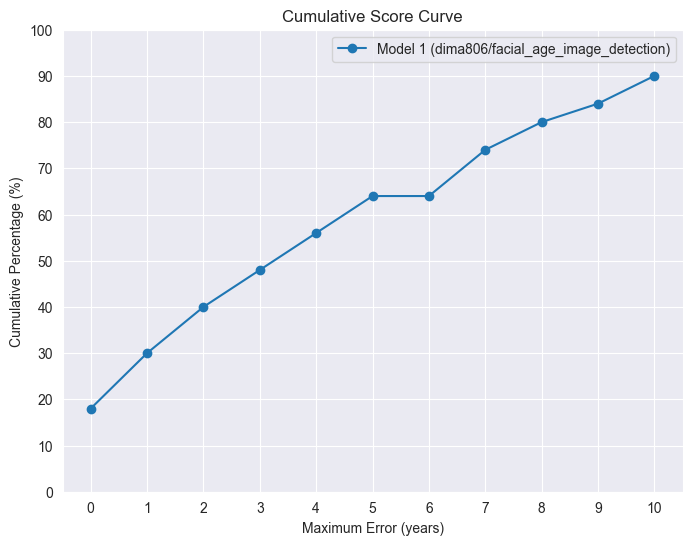

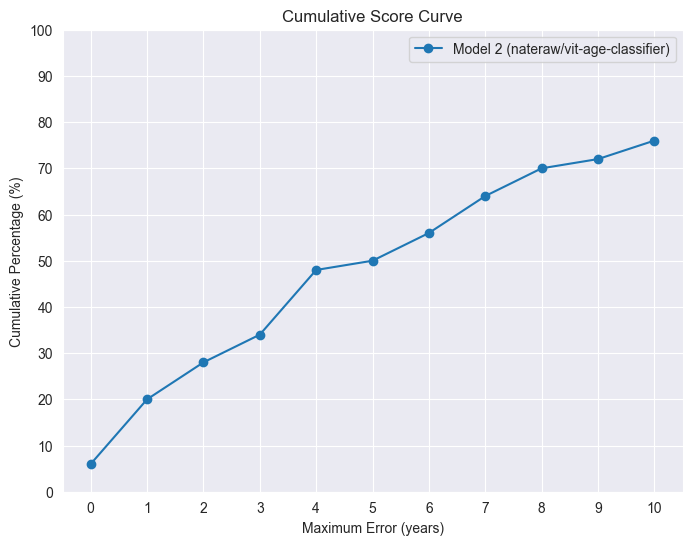

In [43]:
# 18. Plot Cumulative Score Curves
def plot_cumulative_score(true, pred, model_name, max_error=10):
    """
    Plots the cumulative percentage of predictions within a specified error range.

    Parameters:
    - true (array): True age labels.
    - pred (array): Predicted age labels.
    - model_name (str): Name of the model.
    - max_error (int): Maximum error to consider.
    """
    errors = np.abs(true - pred)
    cumulative = [np.mean(errors <= i) * 100 for i in range(max_error + 1)]

    plt.figure(figsize=(8,6))
    plt.plot(range(max_error + 1), cumulative, marker='o', label=model_name)
    plt.title('Cumulative Score Curve')
    plt.xlabel('Maximum Error (years)')
    plt.ylabel('Cumulative Percentage (%)')
    plt.grid(True)
    plt.legend()
    plt.xticks(range(0, max_error + 1, 1))
    plt.yticks(range(0, 101, 10))
    plt.show()

# Plot for Model 1
plot_cumulative_score(true_ages, pred_model1, 'Model 1 (dima806/facial_age_image_detection)')

# Plot for Model 2
plot_cumulative_score(true_ages, pred_model2, 'Model 2 (nateraw/vit-age-classifier)')


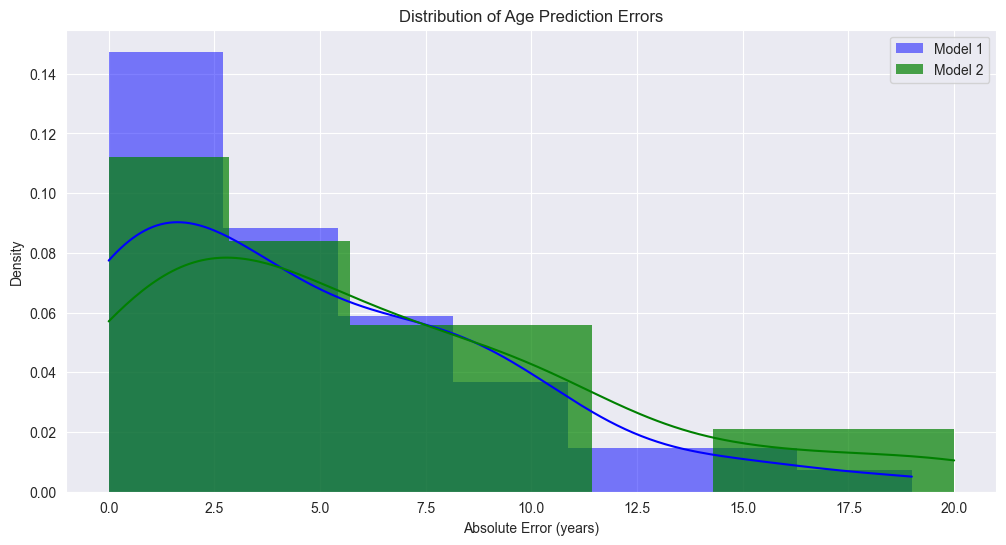

In [44]:
# 19. Distribution of Errors
errors_model1 = np.abs(true_ages - pred_model1)
errors_model2 = np.abs(true_ages - pred_model2)

plt.figure(figsize=(12,6))
sns.histplot(errors_model1, color='blue', label='Model 1', kde=True, stat="density", linewidth=0)
sns.histplot(errors_model2, color='green', label='Model 2', kde=True, stat="density", linewidth=0, alpha=0.7)
plt.title('Distribution of Age Prediction Errors')
plt.xlabel('Absolute Error (years)')
plt.ylabel('Density')
plt.legend()
plt.show()


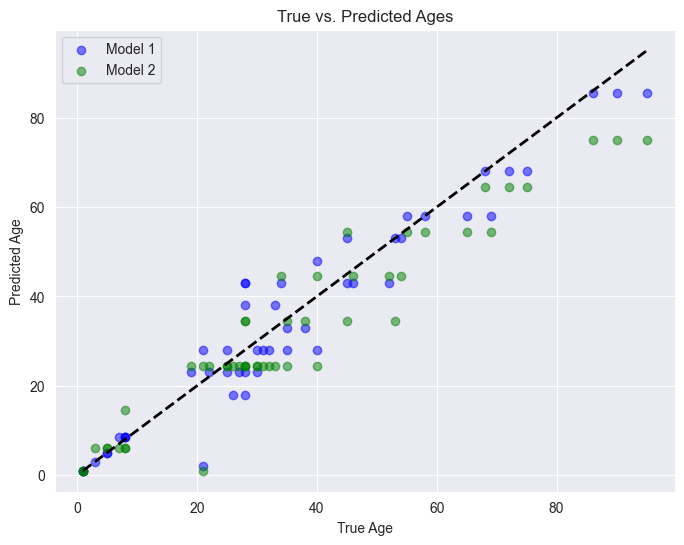

In [45]:
# 20. Scatter Plot (True vs. Predicted Ages)
plt.figure(figsize=(8,6))
plt.scatter(true_ages, pred_model1, color='blue', alpha=0.5, label='Model 1')
plt.scatter(true_ages, pred_model2, color='green', alpha=0.5, label='Model 2')
plt.plot([true_ages.min(), true_ages.max()], [true_ages.min(), true_ages.max()], 'k--', lw=2)
plt.xlabel('True Age')
plt.ylabel('Predicted Age')
plt.title('True vs. Predicted Ages')
plt.legend()
plt.show()


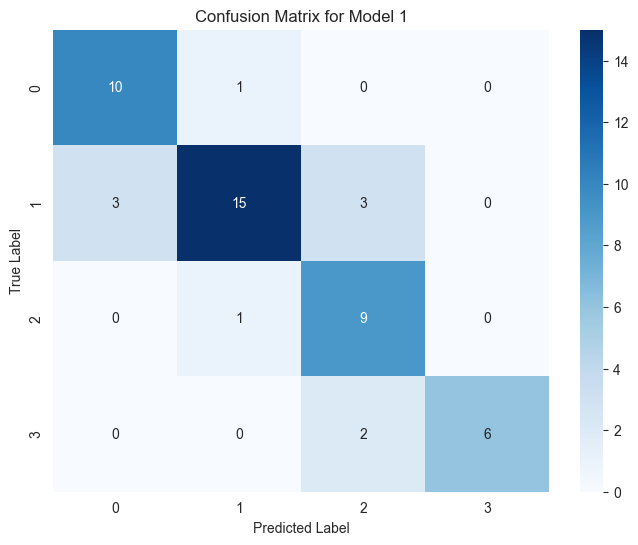

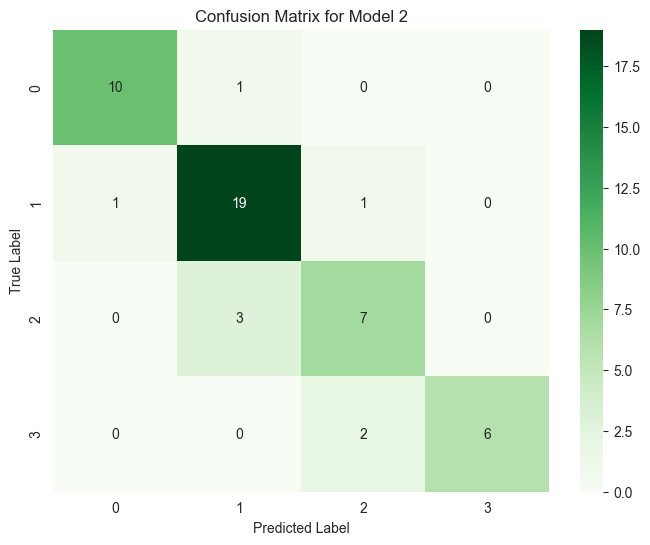

In [46]:
# 21. Confusion Matrix

# Convert ages to age groups
def age_group(age):
    if age < 20:
        return 'Teen'
    elif 20 <= age < 40:
        return 'Young Adult'
    elif 40 <= age < 60:
        return 'Middle-aged'
    else:
        return 'Senior'

true_groups = [age_group(age) for age in true_ages]
pred_groups_model1 = [age_group(age) for age in pred_model1]
pred_groups_model2 = [age_group(age) for age in pred_model2]

# Confusion Matrix for Model 1
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(true_groups, pred_groups_model1, labels=['Teen', 'Young Adult', 'Middle-aged', 'Senior']),
            annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Model 1')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Confusion Matrix for Model 2
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(true_groups, pred_groups_model2, labels=['Teen', 'Young Adult', 'Middle-aged', 'Senior']),
            annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix for Model 2')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()



In [47]:
# 22. Optional: Detailed Classification Report (Age Groups)
print("\nModel 1 (dima806/facial_age_image_detection) Classification Report (Age Groups):")
print(classification_report(true_groups, pred_groups_model1))

print("\nModel 2 (nateraw/vit-age-classifier) Classification Report (Age Groups):")
print(classification_report(true_groups, pred_groups_model2))



Model 1 (dima806/facial_age_image_detection) Classification Report (Age Groups):
              precision    recall  f1-score   support

 Middle-aged       0.64      0.90      0.75        10
      Senior       1.00      0.75      0.86         8
        Teen       0.77      0.91      0.83        11
 Young Adult       0.88      0.71      0.79        21

    accuracy                           0.80        50
   macro avg       0.82      0.82      0.81        50
weighted avg       0.83      0.80      0.80        50


Model 2 (nateraw/vit-age-classifier) Classification Report (Age Groups):
              precision    recall  f1-score   support

 Middle-aged       0.70      0.70      0.70        10
      Senior       1.00      0.75      0.86         8
        Teen       0.91      0.91      0.91        11
 Young Adult       0.83      0.90      0.86        21

    accuracy                           0.84        50
   macro avg       0.86      0.82      0.83        50
weighted avg       0.85      